Load the dataset

In [ ]:
import pandas as pd

In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('Electricity_Theft_Data.csv')
data

,CONS_NO,01-01-15,02-01-15,03-01-15,04-01-15,05-01-15,06-01-15,07-01-15,08-01-15,09-01-15,...,23-12-15,24-12-15,25-12-15,26-12-15,27-12-15,28-12-15,29-12-15,30-12-15,31-12-15,CHK_STATE
0,NaN,1.00,2.00,3.000,4.000,5.00,6.00,7.00,8.00,9.00,...,357.00,358.00,359.00,360.00,361.00,362.00,363.00,364.00,365.00,NaN
1,8.546920e+09,0.00,0.00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0
2,6.177183e+08,1.12,1.73,3.340,2.770,3.50,2.86,1.25,1.12,1.51,...,17.31,15.95,17.00,32.05,28.72,31.11,28.47,16.70,14.96,1.0
3,7.222500e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0
4,7.134080e+09,1.58,3.65,2.540,4.280,1.62,1.39,2.33,1.78,1.80,...,4.17,7.95,8.84,2.20,2.91,10.52,7.98,3.68,1.41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9952,6.460203e+09,3.46,2.83,3.735,3.735,2.65,3.56,3.42,3.39,3.65,...,5.32,5.19,6.04,7.89,6.56,3.90,7.05,5.11,8.07,0.0
9953,3.721000e+08,8.39,6.49,5.340,7.280,5.55,3.89,5.36,5.69,4.95,...,7.91,7.43,6.34,10.34,6.04,7.75,7.49,7.96,9.35,0.0
9954,1.069130e+09,11.33,3.47,4.370,7.370,5.76,5.16,5.79,7.41,5.33,...,5.17,3.97,7.72,3.31,4.58,4.95,3.46,3.59,5.43,0.0
9955,5.571700e+09,13.80,11.22,13.170,10.880,13.52,13.91,15.35,10.73,11.78,...,12.22,11.58,12.03,12.43,16.79,13.18,13.01,10.97,14.96,0.0


Preview the dataset


In [ ]:
print("Dataset shape:", data.shape)
print(data.head())


Dataset shape: (9957, 367)
        CONS_NO  01-01-15  02-01-15  03-01-15  04-01-15  05-01-15  06-01-15  \
0           NaN      1.00      2.00      3.00      4.00      5.00      6.00   
1  8.546920e+09      0.00      0.00      0.00      0.00      0.00      0.00   
2  6.177183e+08      1.12      1.73      3.34      2.77      3.50      2.86   
3  7.222500e+09       NaN       NaN       NaN       NaN       NaN       NaN   
4  7.134080e+09      1.58      3.65      2.54      4.28      1.62      1.39   

   07-01-15  08-01-15  09-01-15  ...  23-12-15  24-12-15  25-12-15  26-12-15  \
0      7.00      8.00      9.00  ...    357.00    358.00    359.00    360.00   
1      0.00      0.00      0.00  ...      0.00      0.00      0.00      0.00   
2      1.25      1.12      1.51  ...     17.31     15.95     17.00     32.05   
3       NaN       NaN       NaN  ...      0.00      0.00      0.00      0.00   
4      2.33      1.78      1.80  ...      4.17      7.95      8.84      2.20   

   27-12-15  28-1

In [ ]:
data.isnull().sum()

,0
CONS_NO,1
01-01-15,1602
02-01-15,1602
03-01-15,1602
04-01-15,1601
...,...
28-12-15,10
29-12-15,7
30-12-15,7
31-12-15,2


In [ ]:
value_counts = data['CHK_STATE'].value_counts()

print("Counts of CHK_STATE values:")
print(value_counts)

Counts of CHK_STATE values:
CHK_STATE
0.0    8562
1.0    1394
Name: count, dtype: int64


In [ ]:
data_ffill = data.fillna(method='ffill')
data_ffill_bfill = data_ffill.fillna(method='bfill')
data_cleaned = data_ffill_bfill.dropna(subset=['CHK_STATE'])



<ipython-input-9-ceeebcba2420>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_ffill = data.fillna(method='ffill')
<ipython-input-9-ceeebcba2420>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_ffill_bfill = data_ffill.fillna(method='bfill')


In [ ]:
cleaned_missing_values = data_cleaned.isnull().sum()
print("Remaining missing values after cleaning:", cleaned_missing_values)


Remaining missing values after cleaning: CONS_NO      0
01-01-15     0
02-01-15     0
03-01-15     0
04-01-15     0
            ..
28-12-15     0
29-12-15     0
30-12-15     0
31-12-15     0
CHK_STATE    0
Length: 367, dtype: int64


In [ ]:
value_counts = data_cleaned['CHK_STATE'].value_counts()
print("Counts of CHK_STATE values:")
print(value_counts)


Counts of CHK_STATE values:
CHK_STATE
0.0    8562
1.0    1395
Name: count, dtype: int64


In [ ]:
# Prepare data for modeling
X_data = data_cleaned.iloc[:, 1:-1].values  # All daily readings
y_data = data_cleaned['CHK_STATE'].values   # Theft indicator (0 = No, 1 = Yes)


In [ ]:
from collections import Counter


In [ ]:
# Handling class imbalance using ADASYN
adasyn = ADASYN(random_state=42)
X_res, y_res = adasyn.fit_resample(X_data, y_data)

In [ ]:
# Check new class distribution after applying ADASYN
print('Counts of CHK_STATE after ADASYN:', Counter(y_res))

Counts of CHK_STATE after ADASYN: Counter({1.0: 8641, 0.0: 8562})


In [ ]:
# Check the new class distribution after applying SMOTE
print('Original class distribution:', Counter(y_data))
print('Resampled class distribution:', Counter(y_res))
from collections import Counter

# Assuming y_res is already defined after SMOTE
value_counts = Counter(y_res)

# Print the counts of 0 and 1
print("Counts in y_res:")
print(f"Count of 0: {value_counts[0]}")
print(f"Count of 1: {value_counts[1]}")


Original class distribution: Counter({0.0: 8562, 1.0: 1395})
Resampled class distribution: Counter({1.0: 8641, 0.0: 8562})
Counts in y_res:
Count of 0: 8562
Count of 1: 8641


In [ ]:
# Split the resampled dataset
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Feature scaling for models like SVM and k-NN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Dynamic classifier selection based on variance
def calculate_variance(data):
    return np.var(data, axis=1)

def select_classifier_based_on_variance(variance, low_thresh=0.5, high_thresh=1.5):
    if variance < low_thresh:
        return 'RandomForest'
    elif variance < high_thresh:
        return 'k-NN'
    else:
        return 'AnomalyDetection'

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier


In [ ]:
# Prepare classifiers
rf = BalancedRandomForestClassifier(random_state=42, class_weight='balanced')
knn = KNeighborsClassifier()
svm = SVC(probability=True, random_state=42)
iso_forest = IsolationForest(random_state=42)


In [ ]:
# Dynamic classifier selection based on variance
def select_classifier_based_on_variance(variance, low_thresh=0.5, high_thresh=1.5):
    if variance < low_thresh:
        return 'RandomForest'
    elif variance < high_thresh:
        return 'k-NN'
    else:
        return 'AnomalyDetection'

In [ ]:
# Prepare classifiers for ensemble
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
knn = KNeighborsClassifier()
svm = SVC(probability=True, random_state=42)
iso_forest = IsolationForest(random_state=42)

In [ ]:
 #Fit the Balanced Random Forest
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [ ]:
svm.fit(X_train_scaled, y_train)


SVC(probability=True, random_state=42)

In [ ]:
iso_forest.fit(X_train_scaled)  # Note: Isolation Forest is typically unsupervised


IsolationForest(random_state=42)

In [ ]:
# Calculate variance for both train and test sets
variance_train = calculate_variance(X_train_scaled)
variance_test = calculate_variance(X_test_scaled)


In [ ]:
selected_classifiers = []


In [ ]:
# Dynamic selection and predictions
y_pred_dynamic = []
variance_test = calculate_variance(X_test_scaled)

for i, test_sample in enumerate(X_test_scaled):
    var = variance_test[i]
    selected_model = select_classifier_based_on_variance(var)
    selected_classifiers.append(selected_model)  # Store selected classifier


    if selected_model == 'RandomForest':
        pred = rf.predict([test_sample])
    elif selected_model == 'k-NN':
        pred = knn.predict([test_sample])
    else:
        pred = iso_forest.fit_predict([test_sample])
        pred = [1] if pred[0] == -1 else [0]

    y_pred_dynamic.append(pred[0])

In [ ]:
from sklearn.metrics import confusion_matrix


In [ ]:
 #Model Evaluation
accuracy = accuracy_score(y_test, y_pred_dynamic)
print("Dynamic Classifier Selection Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred_dynamic))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dynamic))

Dynamic Classifier Selection Accuracy: 0.895562875411742
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.91      0.90      2593
         1.0       0.91      0.88      0.89      2568

    accuracy                           0.90      5161
   macro avg       0.90      0.90      0.90      5161
weighted avg       0.90      0.90      0.90      5161

Confusion Matrix:
 [[2369  224]
 [ 315 2253]]


In [ ]:
from collections import Counter

# After the prediction loop
prediction_counts = Counter(selected_classifiers)

# Total samples
total_samples = len(y_pred_dynamic)

# Print counts
print("Total Samples:", total_samples)
print("Predicted by Random Forest:", prediction_counts.get('RandomForest', 0))
print("Predicted by k-NN:", prediction_counts.get('k-NN', 0))
print("Predicted by Anomaly Detection:", prediction_counts.get('AnomalyDetection', 0))


Total Samples: 5161
Predicted by Random Forest: 4776
Predicted by k-NN: 164
Predicted by Anomaly Detection: 221


#visualization Part

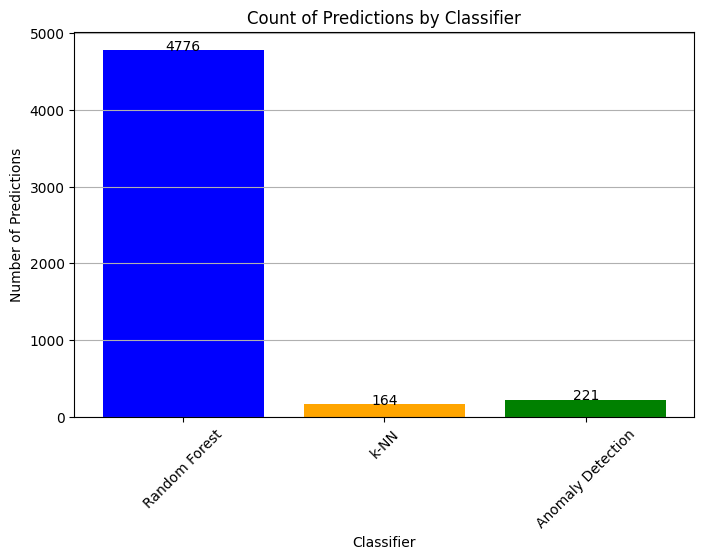

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for visualization
labels = ['Random Forest', 'k-NN', 'Anomaly Detection']
counts = [
    prediction_counts.get('RandomForest', 0),
    prediction_counts.get('k-NN', 0),
    prediction_counts.get('AnomalyDetection', 0)
]

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['blue', 'orange', 'green'])
plt.title('Count of Predictions by Classifier')
plt.xlabel('Classifier')
plt.ylabel('Number of Predictions')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Show the count values on top of the bars
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center')

plt.show()



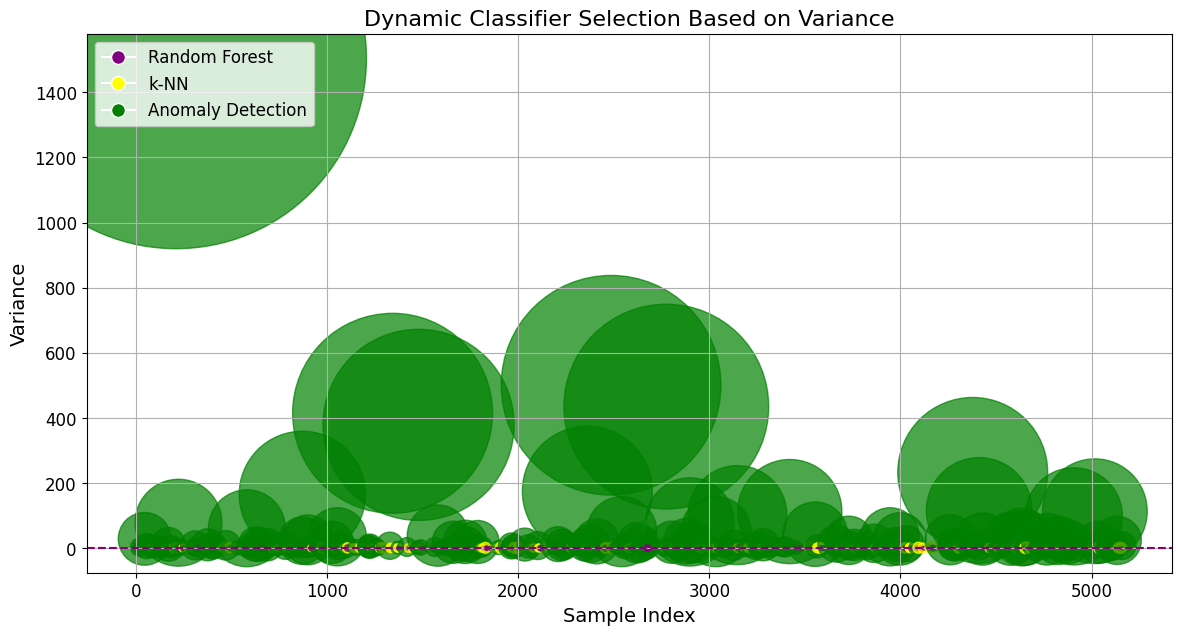

In [ ]:
# Enhanced Visualization
plt.figure(figsize=(14, 7))
color_mapping = {'RandomForest': 'purple', 'k-NN': 'yellow', 'AnomalyDetection': 'green'}
scatter = plt.scatter(range(len(variance_test)), variance_test,
                      c=[color_mapping[cls] for cls in selected_classifiers],
                      alpha=0.7, s=50 * variance_test)  # Size based on variance

# Adding horizontal threshold lines
plt.axhline(y=0.5, color='orange', linestyle='--', label='Low Threshold (0.5)')
plt.axhline(y=1.5, color='purple', linestyle='--', label='High Threshold (1.5)')

# Title and labels
plt.title('Dynamic Classifier Selection Based on Variance', fontsize=16)
plt.xlabel('Sample Index', fontsize=14)
plt.ylabel('Variance', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label='Random Forest', markersize=10, markerfacecolor='purple'),
           plt.Line2D([0], [0], marker='o', color='w', label='k-NN', markersize=10, markerfacecolor='yellow'),
           plt.Line2D([0], [0], marker='o', color='w', label='Anomaly Detection', markersize=10, markerfacecolor='green')]
plt.legend(handles=handles, loc='upper left', fontsize=12)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


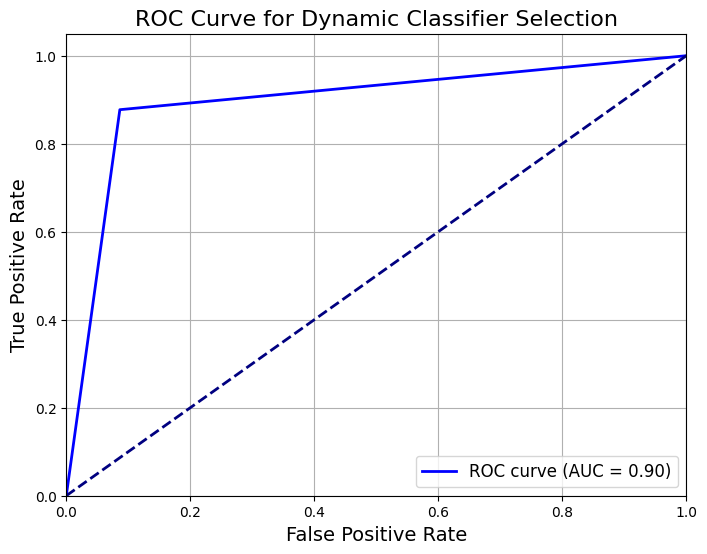

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the ROC curve based on your dynamic predictions
fpr, tpr, _ = roc_curve(y_test, y_pred_dynamic)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_dynamic)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Dynamic Classifier Selection', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate and print the ROC-AUC score for the dynamic predictions
roc_auc = roc_auc_score(y_test, y_pred_dynamic)
print(f'ROC-AUC Score: {roc_auc:.2f}')


ROC-AUC Score: 0.90


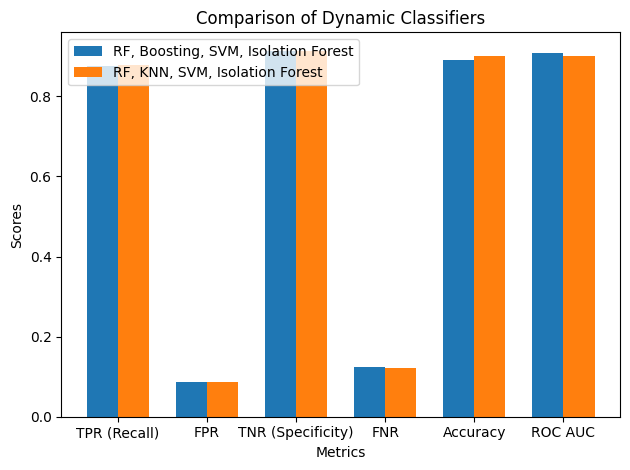

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the classifier names
classifiers = ['RF, Boosting, SVM, Isolation Forest', 'RF, KNN, SVM, Isolation Forest']

# Define the metric names
metrics = ['TPR (Recall)', 'FPR', 'TNR (Specificity)', 'FNR', 'Accuracy', 'ROC AUC']

# Results for the first classifier (RF, Boosting, SVM, Isolation Forest)
results_1 = [0.8755, 0.0860, 0.9140, 0.1245, 0.89, 0.9092]

# Results for the second classifier (RF, KNN, SVM, Isolation Forest)
results_2 = [0.8770, 0.0857, 0.9130, 0.1217, 0.90, 0.90]

# Set the position of the bars on the x-axis
x = np.arange(len(metrics))

# Set the width of the bars
bar_width = 0.35

# Create the figure and axis
fig, ax = plt.subplots()

# Plot bars for each classifier
bars1 = ax.bar(x - bar_width/2, results_1, bar_width, label=classifiers[0])
bars2 = ax.bar(x + bar_width/2, results_2, bar_width, label=classifiers[1])

# Add labels and title
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Dynamic Classifiers')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()
